# 4 · Validate FES2022 against tide gauge

### Verifying that FES2022 predictions match observed water levels

Page 3 checked whether **satellites** sample the tidal cycle well enough. This page
checks whether the **tide model itself** is trustworthy at your site.

Every satellite scene in the workflow gets a tide height from **FES2022**. If that model
systematically over- or under-predicts water level, your intertidal elevation map will
be shifted or distorted — even with perfect satellite coverage.

We compare FES2022 to **RWS tide-gauge** measurements via **`rws-ddlpy`** (Deltares) —
the official Python wrapper for Rijkswaterstaat **WaterWebservices**. This step is
**optional but strongly recommended** for Dutch Wadden Sea and Delta sites where a
nearby WATHTE gauge exists.

**What this notebook answers**

1. Does FES2022 **track** observed water levels over a full year?
2. Is there a **constant bias** (datum mismatch NAP ↔ MSL)?
3. Are errors **larger at high/low tide** (non-astronomical forcing)?
4. Is the model **good enough** to tag scenes for pages 5–6?

**How to read the metrics**

| Metric | Formula (conceptually) | What it tells you |
|---|---|---|
| **Bias** | mean(modelled − observed) | Constant offset. Fix with `NAP_MSL_OFFSET_M` if stable across all tide heights. |
| **MAE** | mean \|error\| | Typical mismatch in metres — most useful single number for mapping. |
| **RMSE** | √(mean error²) | Like MAE but penalises large outliers (storms, surges). |
| **r** | Pearson correlation | Shape agreement (0–1). High r with large bias → correct timing, wrong datum. |
| **Skill** | Nash–Sutcliffe (1 − MSE/var) | 1 = perfect; < 0 worse than using the mean tide height. |

**Rule of thumb before page 6 (elevation mapping)**

| Metric | Good | Acceptable | Poor |
|---|---|---|---|
| **\|Bias\|** | < 5 cm | 5–10 cm — tune datum | > 10 cm — fix before mapping |
| **MAE** | < 10 cm | 10–20 cm — note uncertainty | > 20 cm — investigate |
| **RMSE** | < 12 cm | 12–25 cm | > 25 cm |
| **r** | > 0.95 | 0.90–0.95 | < 0.90 |
| **Skill** | > 0.90 | 0.75–0.90 | < 0.75 |

> **Station names changed (2025):** the API now uses dotted ids like
> `denhelder.marsdiep` instead of short codes like `DENHDR`. Legacy codes still work
> via aliases in `cache_utils`.

**Previous:** [3 · Tides](03_tides.ipynb) · **Next:** [5 · NDWI](05_ndwi.ipynb)


## Step 1 — Imports

We load the libraries used in this notebook:

- **`ddlpy`** — download RWS water-level time series (WATHTE).
- **`cache_utils`** — cached gauge download and the same FES2022 series as page 3.
- **`matplotlib`** — time series, scatter, and error plots in Steps 6–7.

`rws-ddlpy` is installed with the project environment (`uv sync`). No separate
`pip install` needed.


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import ddlpy
from cache_utils import load_or_compute_tides, load_or_compute_gauge, list_gauge_stations

warnings.filterwarnings("ignore")
print("Imports OK. ddlpy:", ddlpy.__version__)


Imports OK. ddlpy: 0.10.0


## Step 2 — Configuration

Choose the **RWS tide-gauge closest to your study site**. The model is evaluated at the
**gauge coordinates**, not your mapping polygon centre — pick a station within ~10–20 km
of the flats you will map.

You can use a **legacy code** (from the table) or a **ddlpy location id**
(e.g. `denhelder.marsdiep`).

| Legacy code | Location | ddlpy id (example) |
|---|---|---|
| `HOEKVHLD` | Hoek van Holland | `hoekvanholland` |
| `DENHDR` | Den Helder | `denhelder.marsdiep` |
| `HARLGN` | Harlingen | `harlingen.waddenzee` |
| `DELFZL` | Delfzijl | `delfzijl` |
| `VLISSGN` | Vlissingen | `vlissingen` |
| `YERSEKE` | Yerseke | `yerseke` |
| `ROOMPOT` | Oosterschelde mouth | `oosterschelde.roompotsluis.buiten` |

**Finding a station:** run the search cell below with a place name. Pick a row with
**WATHTE** water level on **NAP** — not a sluice, wind, or discharge sensor.

**Key settings**

| Variable | Role |
|---|---|
| `START` / `END` | Validation window — use the **same period** as page 3 when possible. |
| `NAP_MSL_OFFSET_M` | Subtract from gauge (NAP) to align with FES2022 (MSL). Start at `0.0`; adjust if Step 5 shows a stable bias. |
| `OVERWRITE` | `True` re-downloads gauge data; FES2022 cache is shared with page 3. |

`NAP ≈ MSL` at most Dutch open-coast stations. A **constant** bias in Step 5 usually
means this offset needs tuning, not that FES2022 is wrong.


In [2]:
# Search tide-gauge stations by place name (optional)
list_gauge_stations("den helder")   # try: hoek, harlingen, vlissingen, yerseke


,Code,Naam,Lat,Lon,Groepering.Code
0,denhelder.marsdiep,"Den Helder, Marsdiep",52.964359,4.744990,
2,denhelder.veersteiger,"Den Helder, veersteiger",52.963274,4.778047,


In [3]:
# === EDIT THESE ===
STATION_CODE     = "DENHDR"          # legacy code OR ddlpy id, e.g. denhelder.marsdiep
SITE_NAME        = "Den Helder"

TIDE_DIR         = "./tide_models"
TIDE_MODEL       = "FES2022"

START            = "2023-01-01"
END              = "2023-12-31"
NAP_MSL_OFFSET_M = 0.0    # metres; refine if bias is non-zero

OVERWRITE = False   # set True to re-download gauge data

os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
print(f"Station : {STATION_CODE}  ({SITE_NAME})")
print(f"Window  : {START} to {END}")
print(f"NAP-MSL : {NAP_MSL_OFFSET_M:+.3f} m")


Station : DENHDR  (Den Helder)
Window  : 2023-01-01 to 2023-12-31
NAP-MSL : +0.000 m


## Step 3 — Load or download gauge data (ddlpy)

`load_or_compute_gauge` looks up the station coordinates, then either loads the cached
Parquet or downloads from the RWS DDL API (typically 1–3 minutes for a multi-year window).

**What to check in the printed output**

| Output line | Good sign | Warning sign |
|---|---|---|
| **Clean records** | Thousands of hourly points for 1 year | Very few rows — wrong sensor or date range |
| **Range (m, MSL)** | Matches expected tidal amplitude (~1–3 m Wadden; ~1–2 m Delta) | Flat line (< 0.3 m) — wrong quantity or datum |
| **Station coords** | Near your study site | Gauge far from mapping area — validation less representative |


In [4]:
gauge_df, meta = load_or_compute_gauge(
    station_code=STATION_CODE,
    start=START, end=END,
    nap_msl_offset_m=NAP_MSL_OFFSET_M,
    overwrite=OVERWRITE,
)

gauge_lon, gauge_lat = meta["lon"], meta["lat"]
print(f"\nStation coords : {gauge_lat:.4f} N, {gauge_lon:.4f} E")
print(f"Clean records  : {len(gauge_df):,}")
print(f"Range          : {gauge_df['water_level_m_MSL'].min():.3f} m to "
      f"{gauge_df['water_level_m_MSL'].max():.3f} m (MSL)")

if "time" not in gauge_df.columns:
    gauge_df = gauge_df.reset_index()


  Loaded from cache ← cache/gauge_DENHDR_2023-01-01_2023-12-31.parquet  (52,417 rows)

Station coords : 52.9644 N, 4.7450 E
Clean records  : 52,417
Range          : -1.200 m to 0.990 m (MSL)


### Interpreting Step 3

The gauge series is your **ground truth** for this validation. RWS WATHTE data are
quality-controlled and reported in **cm + NAP**; we convert to **metres + MSL** for
comparison with FES2022.

- **Gaps in the record** — brief outages are normal; resampling to hourly (Step 4)
  handles minor missing data.
- **Range much smaller than page 3 HAT–LAT** — check you selected WATHTE (not a
  secondary sensor) and the correct station.
- **Gauge far from your AOI** — FES2022 may still be fine at the flats, but this
  validation is weaker; mention the distance in your methods section.


## Step 4 — Align FES2022 with gauge observations

We use the same `load_or_compute_tides` cache as page 3. If you already ran that notebook
for the same location and period, the FES2022 series loads instantly.

**Alignment logic**

1. Resample gauge to **hourly** means (RWS is already ~10 min; hourly is enough).
2. For each gauge timestamp, pick the **nearest FES2022 value** within ±31 minutes
   (half of the 30-min model interval).
3. Drop hours with no model match — should be zero if both series cover the same period.

The result is `comparison`: two columns, **observed** (gauge) and **modelled** (FES2022),
same timestamps, same datum (MSL).


In [5]:
# The gauge is already hourly; resample just in case
if "time" not in gauge_df.columns:
    gauge_df = gauge_df.reset_index()

gauge_hourly = (gauge_df.set_index("time")["water_level_m_MSL"]
                .resample("h").mean().dropna())

# Load or compute the continuous FES2022 series at the gauge location
heights_full = load_or_compute_tides(
    lon=gauge_lon, lat=gauge_lat,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=OVERWRITE,
)

# Align to the hourly gauge timestamps
modelled = heights_full.reindex(gauge_hourly.index, method="nearest",
                                tolerance=pd.Timedelta("31min"))
modelled.name = "fes2022_m_MSL"

comparison = pd.DataFrame({
    "observed": gauge_hourly,
    "modelled": modelled,
}).dropna()

print(f"Matched {len(comparison):,} hourly pairs.")

  Loaded from cache ← cache/tides_Den_Helder_2023-01-01_2023-12-31.parquet  (17,473 rows)
Matched 8,737 hourly pairs.


### Interpreting Step 4

- **Matched N hourly pairs** should be close to `365 × 24 ≈ 8,760` for one full year
  (minus gauge gaps). Much fewer → check `START`/`END` or re-download with `OVERWRITE = True`.
- This step does **not** prove the model is good yet — it only builds the paired dataset
  for Steps 5–7.
- FES2022 is **barotropic astronomical** only. Gauge observations include **weather**
  effects (surges, set-up). Some mismatch is expected and does not always block mapping.


## Step 5 — Validation metrics

We summarise the paired series with standard hydrographic statistics. These numbers
belong in your **methods / uncertainty** section when you cite FES2022.

**How to read each metric**

| Metric | Good | Acceptable | Poor | Typical cause if poor |
|---|---|---|---|---|
| **Bias** | \|b\| < 5 cm | 5–10 cm | > 10 cm | Datum offset → `NAP_MSL_OFFSET_M` |
| **MAE** | < 10 cm | 10–20 cm | > 20 cm | Distance to gauge, surges, wrong station |
| **RMSE** | < 12 cm | 12–25 cm | > 25 cm | Storm events (outliers inflate RMSE) |
| **r** | > 0.95 | 0.90–0.95 | < 0.90 | Wrong location, bad period, major datum error |
| **Skill** | > 0.90 | 0.75–0.90 | < 0.75 | Model no better than the mean tide |

**Decision guide**

| Outcome | Action |
|---|---|
| MAE < 10 cm, \|bias\| < 5 cm | **Proceed** to page 5 (NDWI) or page 6 (elevation) with confidence |
| MAE 10–20 cm, high r | **Proceed with caution** — report MAE as tide uncertainty |
| Large \|bias\|, high r | **Adjust** `NAP_MSL_OFFSET_M` by ≈ −bias, re-run from Step 3 |
| Low r or MAE > 20 cm | **Investigate** station choice, period, or model path before mapping |


In [6]:
diff = comparison["modelled"] - comparison["observed"]
bias = float(diff.mean())
mae  = float(diff.abs().mean())
rmse = float(np.sqrt((diff**2).mean()))
r    = float(comparison.corr().iloc[0, 1])
ss   = float(1 - (diff**2).mean() / comparison["observed"].var())

print(f"Validation — FES2022 vs. RWS gauge ({STATION_CODE}, {START}–{END})")
print(f"  n      : {len(comparison):,}")
print(f"  Bias   : {bias:+.4f} m  ({bias*100:+.1f} cm)")
print(f"  MAE    : {mae:.4f} m  ({mae*100:.1f} cm)")
print(f"  RMSE   : {rmse:.4f} m  ({rmse*100:.1f} cm)")
print(f"  r      : {r:.4f}")
print(f"  Skill  : {ss:.4f}")

# Rule-of-thumb flags (same thresholds as the intro table)
flags = []
if abs(bias) > 0.10:
    flags.append(f"LARGE BIAS ({bias*100:+.1f} cm) — adjust NAP_MSL_OFFSET_M before mapping")
elif abs(bias) > 0.05:
    flags.append(f"MODERATE BIAS ({bias*100:+.1f} cm) — consider tuning NAP_MSL_OFFSET_M")
if mae > 0.20:
    flags.append(f"HIGH MAE ({mae*100:.0f} cm) — investigate station, datum, or surges")
elif mae > 0.10:
    flags.append(f"MODERATE MAE ({mae*100:.0f} cm) — report as tide uncertainty in methods")
if rmse > 0.25:
    flags.append(f"HIGH RMSE ({rmse*100:.0f} cm) — check for storm outliers")
if r < 0.90:
    flags.append(f"LOW CORRELATION (r={r:.3f}) — model may not represent this site")
elif r < 0.95:
    flags.append(f"MODERATE CORRELATION (r={r:.3f}) — acceptable if MAE is low")
if ss < 0.75:
    flags.append(f"LOW SKILL ({ss:.3f}) — model barely beats the mean tide")

status = "OK" if not flags else "WARNING"
print()
print("=" * 60)
print(f"[{status}] FES2022 validation — {SITE_NAME}")
print("=" * 60)
for f in flags:
    print(f"  ⚠  {f}")
if not flags:
    print("  ✓  All rule-of-thumb checks passed — good for intertidal mapping.")
print()
if status == "OK" and mae < 0.10:
    print("OVERALL: GOOD — proceed to page 5 (NDWI).")
elif status == "WARNING" and mae < 0.20 and r > 0.90:
    print("OVERALL: CAUTION — mapping may work; report MAE and note meteorological mismatch.")
else:
    print("OVERALL: POOR — fix datum offset or station choice before page 6 (elevation).")
print("=" * 60)


Validation — FES2022 vs. RWS gauge (DENHDR, 2023-01-01–2023-12-31)
  n      : 8,737
  Bias   : +0.0007 m  (+0.1 cm)
  MAE    : 0.1069 m  (10.7 cm)
  RMSE   : 0.1346 m  (13.5 cm)
  r      : 0.9690
  Skill  : 0.9258

  ~  MAE 11 cm — acceptable; note as model uncertainty.


## Step 6 — Visualise

Three panels help you **trust** the numbers from Step 5:

| Panel | What to look for | Good | Bad |
|---|---|---|---|
| **Time series** (top) | Red dashed (FES2022) follows blue (gauge) | Curves overlap; same phase | Fixed vertical shift → datum; wrong phase → location/period |
| **Scatter** (bottom left) | Points on the 1:1 line | Tight cloud on diagonal | Systematic offset from line → bias; spread → noise/surges |
| **Error histogram** (bottom right) | Centreed on zero, narrow | Symmetric, peak near 0 | Shifted peak → bias; fat tails → storms/outliers |

The July window is shown for readability; metrics in Step 5 use the **full year**.


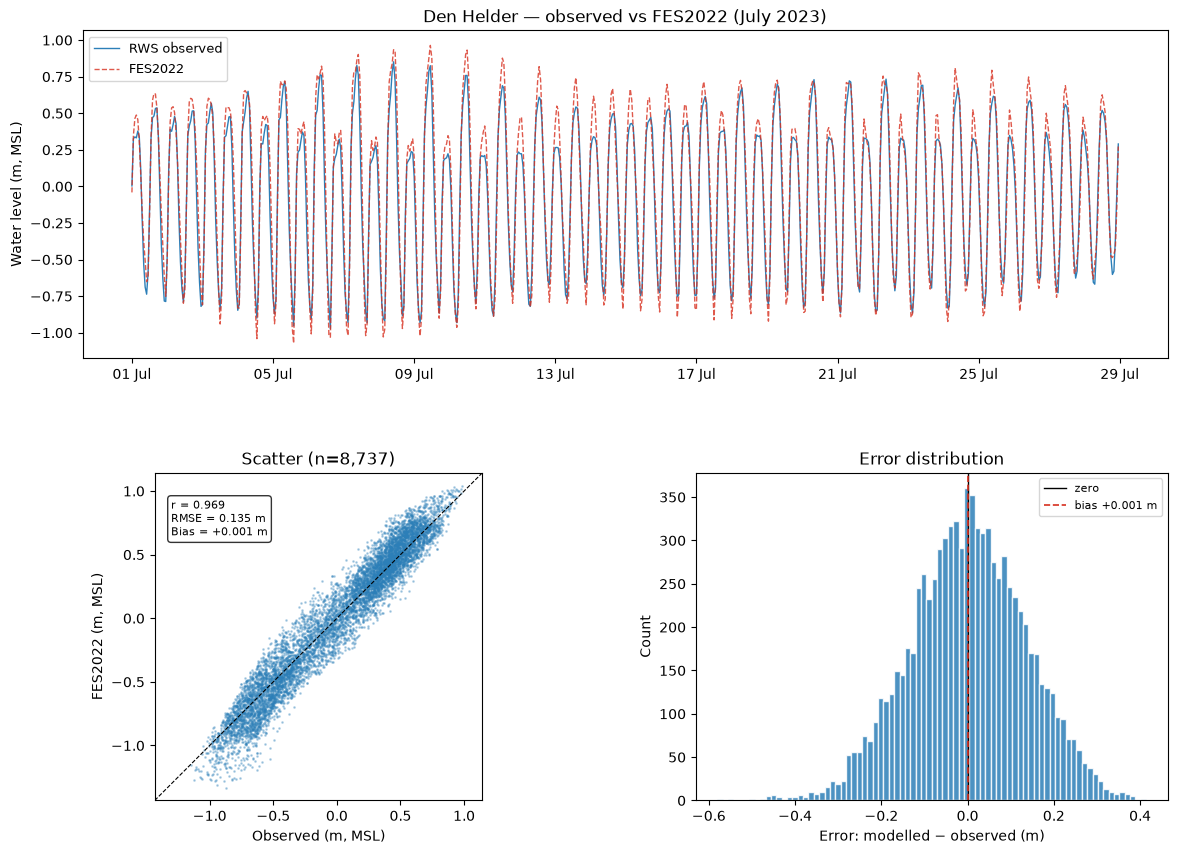

In [7]:
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Time series
ax1 = fig.add_subplot(gs[0, :])
win = comparison.loc["2023-07-01":"2023-07-28"]
ax1.plot(win.index, win["observed"], lw=1.0, color="#2c7fb8", label="RWS observed")
ax1.plot(win.index, win["modelled"], lw=1.0, color="#d7301f", alpha=0.8,
         ls="--", label="FES2022")
ax1.set_ylabel("Water level (m, MSL)")
ax1.set_title(f"{SITE_NAME} — observed vs FES2022 (July 2023)")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Scatter
ax2 = fig.add_subplot(gs[1, 0])
vmin = comparison.min().min() - 0.1
vmax = comparison.max().max() + 0.1
ax2.scatter(comparison["observed"], comparison["modelled"],
            s=1, alpha=0.3, color="#2c7fb8", rasterized=True)
ax2.plot([vmin, vmax], [vmin, vmax], "k--", lw=0.8)
ax2.set_xlabel("Observed (m, MSL)"); ax2.set_ylabel("FES2022 (m, MSL)")
ax2.set_title(f"Scatter (n={len(comparison):,})")
ax2.set_xlim(vmin, vmax); ax2.set_ylim(vmin, vmax)
ax2.set_aspect("equal")
ax2.text(0.05, 0.92, f"r = {r:.3f}\nRMSE = {rmse:.3f} m\nBias = {bias:+.3f} m",
         transform=ax2.transAxes, fontsize=8, va="top",
         bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Error histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(diff.values, bins=80, color="#2c7fb8", edgecolor="white", alpha=0.85)
ax3.axvline(0,    color="k",       lw=1,   ls="-",  label="zero")
ax3.axvline(bias, color="#d7301f", lw=1.2, ls="--", label=f"bias {bias:+.3f} m")
ax3.set_xlabel("Error: modelled − observed (m)")
ax3.set_ylabel("Count"); ax3.set_title("Error distribution")
ax3.legend(fontsize=8)

fig.savefig(f"{SITE_NAME.replace(' ','_')}_FES2022_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Interpreting Step 6

Ask yourself:

1. **Do the curves overlap in phase?** If yes but vertically shifted → tune
   `NAP_MSL_OFFSET_M` (subtract the bias from Step 5).
2. **Does the scatter hug the 1:1 line?** A tight cloud with r > 0.95 confirms FES2022
   captures the tidal **shape** even if a small bias remains.
3. **Is the histogram symmetric?** A bell centred on zero means random noise. A peak
   at +5 cm means the model is consistently too high.
4. **Spikes in the time series** where red and blue diverge briefly — often **storm
   surges** or **wind set-up**. FES2022 does not model these; a few spikes are normal
   in winter and should not alone disqualify the model for intertidal work.

Saved figure: `<site_name>_FES2022_validation.png` (from `SITE_NAME`) — useful for reports and papers.


## Step 7 — RMSE by tidal phase

Split the validation by **observed tide height** (20 bins from lowest to highest water).
This reveals whether errors are **uniform** or **worse near HAT/LAT**.

FES2022 is an **astronomical** tide model. Gauge data also contain **meteorological**
components. Errors often grow near **high water** during storms and near **extremes**
when non-tidal forcing is largest.


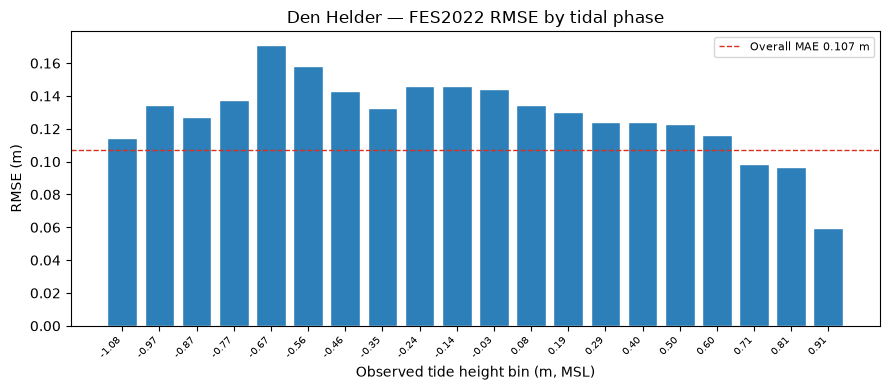

In [8]:
n_bins = 20
comparison["obs_bin"] = pd.cut(comparison["observed"], bins=n_bins)
bin_rmse    = comparison.groupby("obs_bin", observed=True).apply(
    lambda g: np.sqrt(((g["modelled"] - g["observed"])**2).mean()))
bin_centres = comparison.groupby("obs_bin", observed=True)["observed"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(bin_rmse)), bin_rmse.values, color="#2c7fb8", edgecolor="white")
ax.set_xticks(range(len(bin_centres)))
ax.set_xticklabels([f"{v:.2f}" for v in bin_centres.values],
                   rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Observed tide height bin (m, MSL)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{SITE_NAME} — FES2022 RMSE by tidal phase")
ax.axhline(mae, color="#d7301f", ls="--", lw=1, label=f"Overall MAE {mae:.3f} m")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Interpreting Step 7

| Pattern in the bar chart | Meaning | Action |
|---|---|---|
| **Flat bars** (~same RMSE in all bins) | Errors are uniform; mostly datum or background noise | A constant `NAP_MSL_OFFSET_M` fix is appropriate |
| **Higher bars at both ends** (U-shape) | Datum offset **plus** extra error at extremes | Tune datum first; expect residual error at HAT/LAT |
| **High bars only at high tide** | Surge / set-up not in FES2022 | Normal for Dutch coast; note in discussion |
| **High bars only at low tide** | Shallow-water or local bathymetry effects | Check gauge exposure; may still be OK if MAE is low |
| **One isolated high bar** | Single storm event in that bin | Inspect time series (Step 6) for outliers |

**Rule of thumb:** if overall MAE < 10 cm and phase RMSE stays below ~15 cm in most
bins, the model is **fit for purpose** for tagging satellite tide heights.


## Step 8 — What you have seen (recap)

In this notebook you built one validation story in four layers:

1. **Gauge truth (Step 3)** — RWS WATHTE at the nearest station, converted to MSL.
2. **Model predictions (Step 4)** — FES2022 at the same coordinates, aligned hour by hour.
3. **Summary statistics (Step 5)** — bias, MAE, RMSE, r, skill + printed verdict.
4. **Visual and phase checks (Steps 6–7)** — trust the table; diagnose datum vs surges.

Nothing here downloads satellite pixels. You are checking that the **tide tag** applied
to every scene in page 3 is defensible before pages 5–6 use those tags for NDWI and elevation mapping.

### How to read the Step 5 verdict

| Tag / line | Meaning |
|---|---|
| **`[OK]`** | No rule-of-thumb warnings |
| **`[WARNING]`** | At least one ⚠ line — read each flag |
| **`OVERALL: GOOD`** | MAE and bias within good thresholds — go to page 5 (NDWI) |
| **`OVERALL: CAUTION`** | Usable with documented uncertainty (typical for Wadden with surges) |
| **`OVERALL: POOR`** | Fix datum, station, or period before mapping |

### Simple go / no-go

| Situation | Interpretation |
|---|---|
| **GOOD** + scatter on 1:1 line | **Proceed** — cite FES2022 + report MAE |
| **CAUTION** + high r, MAE 10–20 cm | **Proceed** — report MAE as ± uncertainty on tide tags |
| Large bias, high r | **Fix datum** — set `NAP_MSL_OFFSET_M ≈ −bias`, re-run |
| Low r or MAE > 20 cm | **Stop** — wrong gauge, period, or model setup |
| High RMSE only at high tide in Step 7 | Often **acceptable** — astronomical model vs surges |

### Reporting in your paper / report

Include: station name and code, coordinates, period, n pairs, bias, MAE, RMSE, r.
Example: *"FES2022 was validated against RWS gauge denhelder.marsdiep (2023); MAE =
8.2 cm, r = 0.97 (n = 8,712 hourly pairs)."*

If MAE is larger than expected:

- **Constant bias, all phases** → datum offset (`NAP_MSL_OFFSET_M`).
- **Larger errors at extremes** → meteorological forcing not in a barotropic model
  (storm surges, wind set-up). State this limitation explicitly.
- **Cross-check** with a GESLA gauge: `eo_tides.validation.load_gauge_gesla`.

### Cache files

```
cache/
  gauge_<station>_<start>_<end>.parquet   ← Step 3 (RWS WATHTE)
  tides_<site>_<start>_<end>.parquet      ← Step 4 (shared with page 3)
```

Set `OVERWRITE = True` in Step 2 when you change station, dates, or `NAP_MSL_OFFSET_M`.

**References:**
- Lyard, F.H. et al. (2021). FES2022. *Ocean Science*.
- Bishop-Taylor, R. et al. (2019). Between the tides. *ECSS*.

**Next:** [5 · NDWI](05_ndwi.ipynb)
